# Life Cycle Assessment - ECATS scenarios

> **⚠ This notebook has been developed with the AeroMAPS version v0.7.1-beta for obtaining the paper results. However, this notebook has been or could be modified in order to be executable with the latest versions of AeroMAPS, which sometimes leads to different results compared to the ones from the paper, due to some models' modifications. In order to retrieve the results of the paper, one can use the v0.7.1-beta version associated with the original notebook.**

The LCA module performs an environmental assessment of the scenarios using data from both AeroMAPS (e.g., fuel combustion emission factors) and the ecoinvent database (for background processes such as electricity generation). In this case study, the environmental profiles of the various fuel production pathways (biofuels and electrofuels) are entirely based on *ecoinvent* data (completed by *premise*) rather than AeroMAPS models. In particular, the some environmental characteristics of the fuel pathways provided in the `energy_inputs.yaml` files are overrode by ecoinvent data in the LCA module (for example the mean CO2 emission factor). While this approach ensures broader coverage of environmental processes, it may also lead to results that are not fully consistent with those generated by AeroMAPS’ core impact models.

## Load modules

First, the user has to load the framework and generate a process.

In [1]:
# --- Import libraries ---
%matplotlib widget
import pandas as pd
import brightway2 as bw
import lca_algebraic as agb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import collections
import time
import sys

sys.path.insert(0, "./utils/")
from plots import plot_stacked_evolution_subplots
from aeromaps import create_process

plt.style.use("bmh")

## Scenario IS0

In [14]:
# --- Set AeroMAPS models and create process for scenario IS0 ---
# Note: first call to LCA module takes several dozen minutes depending on CPU, as it will install ecoinvent/premise databases (unless previsouly installed)
# and parametrize the LCA model declared in LCA configuration file (each time the kernel is restarted).
process = create_process(
    configuration_file="data/config_files/lca/config_is0medium_lca.yaml",
)

# For check only: check which LCA databases were installed
list(bw.databases)

===== LCA Default Model Import =====


Import LCA Parameters:   0%|          | 0/45 [00:00<?, ?it/s]

Import LCIA functions (axis 'phase'):   0%|          | 0/36 [00:00<?, ?it/s]

Import functional units:   0%|          | 0/1 [00:00<?, ?it/s]

Import impacts metadata:   0%|          | 0/36 [00:00<?, ?it/s]

['Foreground DB']

In [15]:
# --- Run assessment ---
start_time = time.time()
process.compute()
process.write_json()
print("--- %s seconds ---" % (time.time() - start_time))

Running MDA


/Users/f.pollet/POSTDOC/5 - Tools/AeroMAPS/aeromaps/models/impacts/life_cycle_assessment/life_cycle_assessment_default.py:227: UserWarning: Value for LCA parameter "lcaf_mass_consumption" is not provided. Default value 0.0 will be used.
  warnings.warn(
/Users/f.pollet/POSTDOC/5 - Tools/AeroMAPS/aeromaps/models/impacts/life_cycle_assessment/life_cycle_assessment_default.py:227: UserWarning: Value for LCA parameter "lcaf_lhv" is not provided. Default value 0.0 will be used.
  warnings.warn(
/Users/f.pollet/POSTDOC/5 - Tools/AeroMAPS/aeromaps/models/impacts/life_cycle_assessment/life_cycle_assessment_default.py:227: UserWarning: Value for LCA parameter "lcaf_emission_index_nox" is not provided. Default value 0.0 will be used.
  warnings.warn(
/Users/f.pollet/POSTDOC/5 - Tools/AeroMAPS/aeromaps/models/impacts/life_cycle_assessment/life_cycle_assessment_default.py:227: UserWarning: Value for LCA parameter "lcaf_emission_index_sulfur" is not provided. Default value 0.0 will be used.
  warni

--- 5.258761882781982 seconds ---


In [16]:
# --- Outputs ---
process_data_vector_outputs_scenario_0 = process.data["vector_outputs"]
process_data_float_inputs_scenario_0 = process.data["float_inputs"]
process_data_climate_scenario_0 = process.data["climate_outputs"]
lca_outputs_scenario_0 = process.data["lca_outputs"]
lca_outputs_scenario_0

<xarray.DataArray 'lca' (systems: 1, impacts: 36, axis: 20, year: 71)> Size: 409kB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [2.17400037e+07, 2.14905981e+07, 2.12411924e+07, ...,
          1.17303246e+07, 1.17294328e+07, 1.17285410e+07],
         [3.26652359e+08, 3.17819262e+08, 3.19074761e+08, ...,
          1.81712435e+09, 1.87164588e+09, 1.92780320e+09],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
         [2.41710799e-02, 2.39824674e-02, 2.37938549e-02, ...,
          1.57624223e-02, 1.57377923e-02, 1.57131623e-02],
         [3.01951133e-01, 2.93881396e-01, 2.95139091e-01, ...,
          1.68550451e+00, 1.73495715e+00, 1.78585991e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [1.74643122e-05, 1.72953868e-05, 1.71264615e-05, ...,
          9.11693203e-06, 9.09817984e-06, 9.07942765e-06],
         [3.01052531e-04, 2.92781501e-04, 2.93806066e-04, ...,
          1.53234714e-03, 1.57575243e-03, 1.62038285e-03],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]]])
Coordinates:
  * systems  (systems) object 8B 'model'
  * impacts  (impacts) object 288B ('ReCiPe 2016 v1.03, midpoint (H)', 'acidi...
  * axis     (axis) object 160B 'CO2_biofuel' ... 'e_fuel_production'
  * year     (year) float64 568B 2e+03 2.001e+03 ... 2.069e+03 2.07e+03

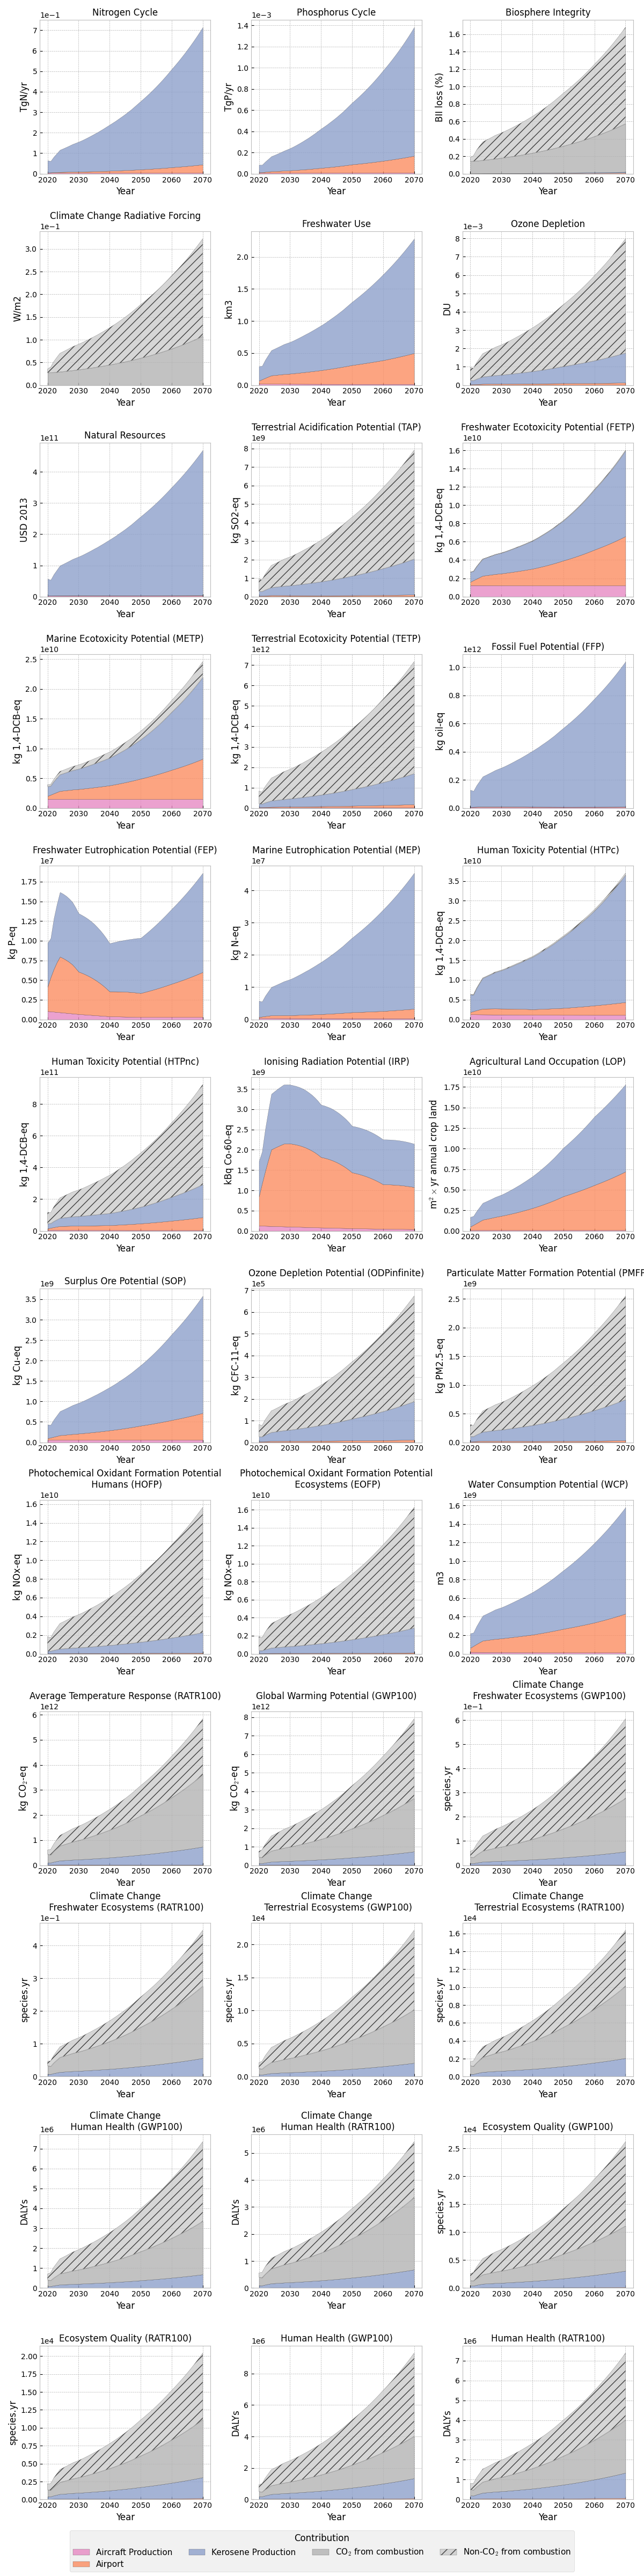

In [17]:
# --- Plot results ---
plt.close()
plot_stacked_evolution_subplots(lca_outputs_scenario_0)#, start_year=2000)

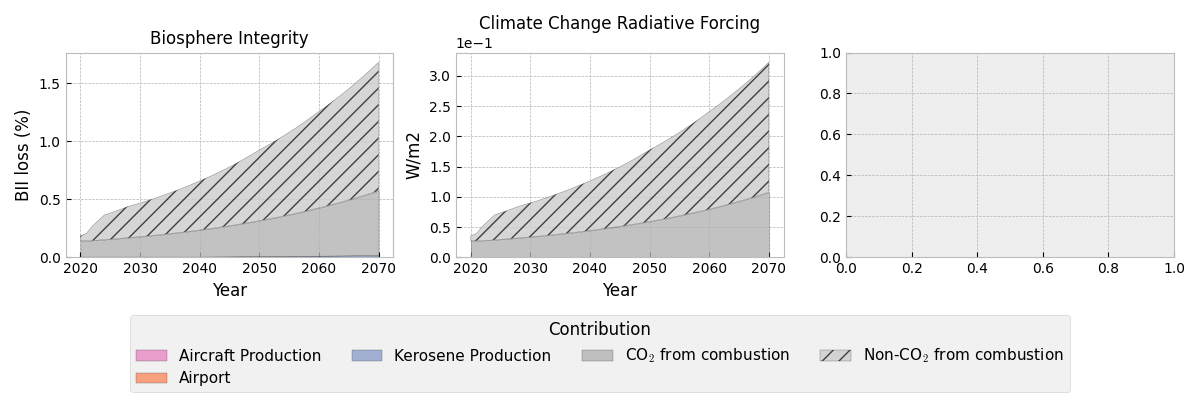

In [13]:
# --- Plot results ---
plt.close()
plot_stacked_evolution_subplots(lca_outputs_scenario_0)#, start_year=2000)

## Scenario IS1

In [ ]:
# --- Create process for scenario IS1 medium ---
process = create_process(
    configuration_file="data/config_files/lca/config_is1medium_lca.yaml",
)

In [ ]:
# --- Run assessment ---
start_time = time.time()
process.compute()
process.write_json()
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
# --- Outputs ---
process_data_vector_outputs_scenario_1 = process.data["vector_outputs"]
process_data_float_inputs_scenario_1 = process.data["float_inputs"]
process_data_climate_scenario_1 = process.data["climate_outputs"]
lca_outputs_scenario_1 = process.data["lca_outputs"]
lca_outputs_scenario_1

In [ ]:
# --- Plot results ---
plt.close()
plot_stacked_evolution_subplots(lca_outputs_scenario_1)

## Scenario IS2

In [ ]:
# --- Create process for scenario IS2 medium ---
process = create_process(
    configuration_file="data/config_files/lca/config_is2medium_lca.yaml",
)

In [ ]:
# --- Run assessment ---
start_time = time.time()
process.compute()
process.write_json()
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
# --- Outputs ---
process_data_vector_outputs_scenario_2 = process.data["vector_outputs"]
process_data_float_inputs_scenario_2 = process.data["float_inputs"]
process_data_climate_scenario_2 = process.data["climate_outputs"]
lca_outputs_scenario_2 = process.data["lca_outputs"]
lca_outputs_scenario_2

In [ ]:
# --- Plot results ---
plt.close()
plot_stacked_evolution_subplots(lca_outputs_scenario_2)

## Scenario IS3

In [ ]:
# --- Create process for scenario IS3 medium ---
process = create_process(
    configuration_file="data/config_files/lca/config_is3medium_lca.yaml",
)

In [ ]:
# --- Run assessment ---
start_time = time.time()
process.compute()
process.write_json()
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
# --- Outputs ---
process_data_vector_outputs_scenario_3 = process.data["vector_outputs"]
process_data_float_inputs_scenario_3 = process.data["float_inputs"]
process_data_climate_scenario_3 = process.data["climate_outputs"]
lca_outputs_scenario_3 = process.data["lca_outputs"]
lca_outputs_scenario_3

In [ ]:
# --- Plot results ---
plt.close()
plot_stacked_evolution_subplots(lca_outputs_scenario_3)

## Planetary Boundaries Assessment

In [ ]:
pb_methods = {
    ('PBLCIA', 'climate change', 'climate change radiative forcing'),
    ('PBLCIA', 'biosphere integrity', 'biosphere integrity'),
    ('PBLCIA', 'biogeochemical', 'nitrogen cycle'),
    ('PBLCIA', 'biogeochemical', 'phosphorus cycle'),
    ('PBLCIA', 'freshwater change', 'freshwater use'),
    ('PBLCIA', 'stratospheric ozone depletion', 'ozone depletion')
}

In [ ]:
def plot_stacked_evolution_subplots(xarray_data, scaling_factors=None, label_y="Impact"):
    """
    Affiche un stacked evolution plot pour les PBLCIA ciblés.
    
    scaling_factors : dict | float | None
        - dict : {pb_tuple: facteur, ...}
        - float : coefficient global
        - None : équivalent à 1
    """
    
    # ---- Préparer DataFrame ----
    df = xarray_data.to_dataframe().reset_index()
    df = df.set_index(["impacts", "axis", "year"])
    df = df.pivot_table(values="lca", index=["impacts", "axis"], columns="year")
    
    df_filtered = df.loc[df.index.get_level_values('impacts').isin(pb_methods)]
    
    # ---- Préparer variables ----
    methods = df_filtered.index.get_level_values("impacts").unique()
    years = sorted(df_filtered.columns)
    
    n_methods = len(methods)
    n_cols = 3
    n_rows = math.ceil(n_methods / n_cols)

    palette = sns.color_palette("Set2", len(df_filtered.index.levels[1]))
    palette_dict = {
        "aircraft_production": (palette[3], ""),
        "airport": (palette[1], ""),
        "kerosene_production": (palette[2], ""),
        "lcaf_production": (palette[4], ""),
        "biofuel_production": (palette[5], ""),
        "e_fuel_production": (palette[8], ""),
        "hydrogen_production": (palette[6], ""),
        "CO2 from combustion": (palette[7], ""),
        "Non-CO2 from combustion": ("0.8", "//"),
    }

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(12, n_rows * 4), constrained_layout=False
    )
    axes = axes.flatten()

    for i, method in enumerate(methods):
        df_method = df_filtered.xs(method, level="impacts")
        df_method.index = df_method.index.str.replace("_other_", "Others")

        # Regroupements CO2 / non-CO2
        co2_rows = df_method.index.str.startswith("CO2")
        if co2_rows.any():
            co2_aggregated = df_method[co2_rows].sum()
            co2_aggregated.name = "CO2 from combustion"
            df_method = pd.concat([df_method[~co2_rows], co2_aggregated.to_frame().T])

        nonco2_rows = df_method.index.str.startswith("non_CO2")
        if nonco2_rows.any():
            nonco2_aggregated = df_method[nonco2_rows].sum()
            nonco2_aggregated.name = "Non-CO2 from combustion"
            df_method = pd.concat([df_method[~nonco2_rows], nonco2_aggregated.to_frame().T])

        df_method = df_method.loc[~(df_method.eq(0).all(axis=1))]

        # 🔑 Facteur d’échelle
        if scaling_factors is None:
            factor = 1.0
        elif isinstance(scaling_factors, dict):
            factor = scaling_factors.get(method, 1.0)  # par défaut 1 si absent
        else:  # scalaire global
            factor = scaling_factors

        df_method = (df_method / factor) * 100

        # Tracé
        colors = [palette_dict[key][0] for key in df_method.index]
        stacks = axes[i].stackplot(
            years,
            df_method,
            labels=df_method.index,
            alpha=0.8,
            colors=colors,
            linewidth=0.2,
        )

        # Nom du subplot
        name = method[2]
        name = name.replace("(with non-CO2)", "").replace("total", "").split("- ")[0]
        name = name.replace(":", "\n")
        name = "".join([a if a.isupper() else b for a, b in zip(name, name.title())])

        if i == 0:  
            name = f"Biogeochemical flows\n{name}"
        if i == 1:  
            name = f"Biogeochemical flows\n{name}"
        if i == 2:  
            name = f"{name}\nLand use + Radiative Forcing*"
        if i == 3:
            name = f"Climate change\nRadiative forcing*"
            
        axes[i].set_title(name, fontsize=12)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel(label_y)
        axes[i].grid(True)
        axes[i].set_axisbelow(True)
        axes[i].ticklabel_format(axis="y", scilimits=(0, 4))
        axes[i].set_facecolor("white")

        hatches = [palette_dict[key][1] for key in df_method.index]
        for stack, hatch, values in zip(stacks, hatches, df_method.values):
            if np.any(values != 0):
                stack.set_edgecolor("0.1")
            if hatch:
                stack.set_hatch(hatch)

    # Légende commune
    all_handles, all_labels = [], []
    for ax in axes[:n_methods]:
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)

    entries = collections.OrderedDict()
    for handle, label in zip(all_handles, all_labels):
        if label == "Others":
            continue
        if label == "CO2 from combustion":
                label_name = label.replace("CO2 from combustion", r"CO$_2$ from combustion (and production if *)")
        elif "CO2" in label:
            label_name = label.replace("CO2", r"CO$_2$")
        elif "e_fuel" in label:
            label_name = label.replace("e_fuel", "E-Fuel").replace("_", " ").title()
        else:
            label_name = label.replace("_", " ").title()
        entries[label_name] = handle

    legend = fig.legend(
        entries.values(),
        entries.keys(),
        loc="lower center",
        bbox_to_anchor=(0.5, 0),
        ncol=4,
        fontsize=11,
        title="Contribution",
        title_fontsize=12,
    )

    bbox = legend.get_window_extent(fig.canvas.get_renderer()).transformed(
        fig.transFigure.inverted()
    )
    fig.tight_layout(rect=(0, bbox.y1, 1, 1), h_pad=0.5, w_pad=0.5)

    plt.show()


In [ ]:
scaling_factors_fhn = {
    ('PBLCIA', 'climate change', 'climate change radiative forcing'): 8.8e-3,
    ('PBLCIA', 'biosphere integrity', 'biosphere integrity'): 1.44e-3,
    ('PBLCIA', 'biogeochemical', 'nitrogen cycle'): 1.0e-2,
    ('PBLCIA', 'biogeochemical', 'phosphorus cycle'): 2.0e-4,
    ('PBLCIA', 'freshwater change', 'freshwater use'): 8.88e1,
    ('PBLCIA', 'stratospheric ozone depletion', 'ozone depletion'): 6.0e-2 
}
scaling_factors_co2emissions = {
    ('PBLCIA', 'climate change', 'climate change radiative forcing'): 2.9e-2,
    ('PBLCIA', 'biosphere integrity', 'biosphere integrity'): 2.9e-1,
    ('PBLCIA', 'biogeochemical', 'nitrogen cycle'): 1.8,
    ('PBLCIA', 'biogeochemical', 'phosphorus cycle'): 2.9e-1,
    ('PBLCIA', 'freshwater change', 'freshwater use'): 1.16e2,
    ('PBLCIA', 'stratospheric ozone depletion', 'ozone depletion'): 4.4e-1 
}
plot_stacked_evolution_subplots(lca_outputs_scenario_2, scaling_factors=scaling_factors_fhn, label_y="Normalised impact under\nethic-based allocation (%)")

In [ ]:
def plot_planetary_radar_2050(xarray_data, scaling_factors=None):
    """
    Planetary Boundaries radar – dégradé par impact
    (version avec lignes radiales et labels lisibles)
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap, LogNorm

    # ==========================
    # Préparation des données
    # ==========================
    df = xarray_data.to_dataframe().reset_index()
    df = df.set_index(["impacts", "axis"])
    df = df.pivot_table(values="lca", index=["impacts", "axis"], columns="year")
    df = df.loc[df.index.get_level_values("impacts").isin(pb_methods)]

    year = 2050
    df_agg = df[year].groupby(level=0).sum()
    df_agg = df_agg[df_agg > 0]

    if scaling_factors is not None:
        if isinstance(scaling_factors, dict):
            scale = pd.Series({k: scaling_factors.get(k, 1.0) for k in df_agg.index})
            df_agg /= scale
        else:
            df_agg /= scaling_factors

    df_agg *= 100  # Conversion en %

    categories = [c[2] if isinstance(c, tuple) else c for c in df_agg.index]
    values = df_agg.values

    # ==========================
    # Paramètres radar
    # ==========================
    N = len(categories)
    theta = np.linspace(0, 2*np.pi, N, endpoint=False)
    width = 2*np.pi / N # * 0.82

    # Rotation des arcs colorés pour aligner
    theta_color = theta - width / 2

    # ==========================
    # Figure
    # ==========================
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    # ==========================
    # Colormap Planetary Boundaries
    # ==========================
    colors = [
        "#2ca25f",  # SAFE (< 100) — vert unique
        "#a6d96a",  # zone tampon
        "#fdae61",  # risque élevé
        "#d73027",  # risque critique
    ]

    bounds = [
        80,
        100,
        500,
        10000
    ]
    pb_cmap = LinearSegmentedColormap.from_list("pb", colors)
    norm = LogNorm(vmin=80, vmax=1000)

    # ==========================
    # Dégradé radial PAR IMPACT
    # ==========================
    r_steps = np.logspace(
        0,
        np.log10(max(values) * 1.1),
        160
    )

    for ang, val in zip(theta_color, values):
        if val < 1:
            continue  # saute cet impact
        for r0, r1 in zip(r_steps[:-1], r_steps[1:]):
            if r0 >= val:
                break
            if r1 > val:
                r1 = val
            ax.bar(
                ang,
                r1 - r0,
                bottom=r0,
                width=width,
                color=pb_cmap(norm(r1)),
                edgecolor=None,
                align="edge",
                log=True,
                zorder=2
            )

    # ==========================
    # Contours noirs
    # ==========================
    for ang, val in zip(theta, values):
        if val < 1:
            continue
        ax.bar(
            ang,
            val-1,
            bottom=1,
            width=width,
            color="none",
            edgecolor="black",
            linewidth=1,
            log=True,
            zorder=3
        )

    # ==========================
    # Lignes radiales fines
    # ==========================
    radial_ticks = [10, 100, 1000, 10000]
    for rt in radial_ticks:
        ax.plot(
            np.linspace(0, 2*np.pi, 400),
            [rt]*400,
            color="gray",
            linewidth=0.7,
            linestyle="--",
            zorder=6
        )

    # ==========================
    # Axes & labels
    # ==========================   
    
    max_radius = 100000
    
    arc_width = 2*np.pi / N # * 0.82
    theta_sep = theta + arc_width / 2  # décalage pour aligner sur le bord de l'arc

    for ang in theta_sep:
        ax.plot(
            [ang, ang],
            [1, max_radius],
            color='gray',
            linewidth=0.8,
            linestyle='--',
            zorder=7
        )
    
    ax.set_xticks(theta)
    labels = [c.replace("_", " ").title() for c in categories]
    labels[0] = 'Nitrogen\nCycle'
    labels[3] = 'Climate\nChange'
    ax.set_xticklabels(
        labels,
        fontsize=11,
        fontweight="bold"
    )
    ax.tick_params(axis='x', pad=20)

    ax.set_ylim(1, max_radius)
    ax.set_yticks([])
    ax.spines['polar'].set_visible(False)

    for rt in radial_ticks:
        ax.text(
            np.deg2rad(270), rt, f"{rt} %",  # texte
            fontsize=10,
            fontweight="bold",
            color="black",
            ha="center",
            va="bottom",  # aligne le texte au-dessus du cercle
            zorder=5  # au-dessus des arcs colorés
        )
        
    ax.grid(False)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_planetary_radar_2050(lca_outputs_scenario_1, scaling_factors=scaling_factors_fhn)

In [ ]:
plot_planetary_radar_2050(lca_outputs_scenario_1, scaling_factors=scaling_factors_co2emissions)